## PREPROCESSING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
df = pd.read_parquet("US_accidents_dataset.parquet")
#RImuovere turning loop inutile tutti i valori sono false
#rimuovere end lat e end long che hanno più del 50% di valori mancanti
#rimuovere aeroporti, informazione ridontante con la latitudine e longitudine e città
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour'] = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

# Rimuovi durate assurde (es. negativi o > 7 giorni)
df = df[(df['duration_min'] >= 0) & (df['duration_min'] < 10080)]

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    
    # Natale e capodanno
    if (m == 12 and d >= 24) or (m == 1 and d <= 2):
        return 1
    # Thanksgiving (novembre, ultima settimana)
    if m == 11 and d >= 22:
        return 1
    # 4 luglio - Independence Day
    if m == 7 and d == 4:
        return 1
    # Memorial Day (fine maggio)
    if m == 5 and d >= 25:
        return 1
    # Labor Day (inizio settembre)
    if m == 9 and d <= 7:
        return 1
    # Halloween
    if m == 10 and d == 31:
        return 1
    # Super Bowl Sunday (prima domenica di febbraio ~7-10 feb)
    if m == 2 and 7 <= d <= 10:
        return 1
    
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)'], inplace=True)
df.drop(columns=['Country'], inplace=True)
def group_weather(w):
    if pd.isna(w):
        return 'Unknown'
    w = str(w).lower()
    
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm']):
        return 'Storm'
    if 'tornado' in w or 'funnel' in w:
        return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing']):
        return 'Snow_Ice'
    if any(x in w for x in ['hail', 'small hail']):
        return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain']):
        return 'Rain'
    if any(x in w for x in ['drizzle', 'shower']):
        return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):
        return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):
        return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):
        return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):
        return 'Clear'
    return 'Other'

def is_windy_condition(w):
    if pd.isna(w):
        return np.nan
    return 1 if 'windy' in str(w).lower() else 0

def weather_intensity(w):
    if pd.isna(w):
        return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']):
        return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):
        return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):
        return 1
    return 0

df['Weather_Group'] = df['Weather_Condition'].apply(group_weather)
df['Weather_Windy'] = df['Weather_Condition'].apply(is_windy_condition)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)

df.drop(columns=['Weather_Condition'], inplace=True)
import re

def classify_street(name):
    if pd.isna(name):
        return 'Unknown'
    name_upper = str(name).upper().strip()
    
    # Rimuovi direzione finale per non confonderla col tipo
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    
    # Interstate highways (I-95, I-10 ecc.)
    if re.match(r'^I-\d+', name_clean):
        return 'Interstate'
    
    # US Routes (US-101, US-1 ecc.)
    if re.match(r'^US-\d+', name_clean):
        return 'US_Route'
    
    # State Routes (CA-99, CA-60 ecc.)
    if re.match(r'^[A-Z]{2}-\d+', name_clean):
        return 'State_Route'
    
    # Freeway con nome (Golden State Fwy, San Diego Fwy ecc.)
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']):
        return 'Freeway_Expressway'
    
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):
        return 'Highway'
    
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):
        return 'Parkway'
    
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']):
        return 'Boulevard'
    
    if any(x in name_clean for x in [' AVE', 'AVENUE']):
        return 'Avenue'
    
    if any(x in name_clean for x in [' RD', ' ROAD']):
        return 'Road'
    
    if any(x in name_clean for x in [' ST', ' STREET']):
        return 'Street'
    
    if any(x in name_clean for x in [' DR', ' DRIVE']):
        return 'Drive'
    
    if any(x in name_clean for x in [' LN', ' LANE']):
        return 'Lane'
    
    if any(x in name_clean for x in [' TRL', ' TRAIL']):
        return 'Trail'
    
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']):
        return 'Local'
    
    return 'Other'


df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

In [3]:
def light_level(row):
    if row['Sunrise_Sunset'] == 'Day':
        return 4  # piena luce
    if row['Civil_Twilight'] == 'Day':
        return 3  # civil twilight
    if row['Nautical_Twilight'] == 'Day':
        return 2  # nautical twilight
    if row['Astronomical_Twilight'] == 'Day':
        return 1  # astronomical twilight
    return 0      # notte piena

df['Light_Level'] = df.apply(light_level, axis=1)
df.drop(columns=['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

df.drop(columns=['ID', 'Source'], inplace=True)

df['desc_length'] = df['Description'].str.len()

# Quante corsie bloccate (più corsie = più grave)
df['lanes_blocked'] = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)

# Tipo di blocco
df['mentions_closed'] = df['Description'].str.contains(r'closed|closure', case=False, na=False).astype(int)
df['mentions_blocked'] = df['Description'].str.contains(r'blocked', case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic', case=False, na=False).astype(int)
df['mentions_slow'] = df['Description'].str.contains(r'slow traffic', case=False, na=False).astype(int)
df['mentions_delay'] = df['Description'].str.contains(r'delay|expect delay', case=False, na=False).astype(int)

# Shoulder bloccata (spalla della strada)
df['mentions_shoulder'] = df['Description'].str.contains(r'shoulder', case=False, na=False).astype(int)

# Incidente non confermato vs confermato
df['unconfirmed'] = df['Description'].str.contains(r'unconfirmed', case=False, na=False).astype(int)

# Veicoli coinvolti
df['multiple_vehicles'] = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)

# Tipo di strada dalla descrizione
df['desc_highway'] = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)

# Caution vs crash confermato
df['drive_caution'] = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed'] = df['Description'].str.contains(r'crash|accident', case=False, na=False).astype(int)

df.drop(columns=['Description'], inplace=True)

bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

In [4]:
df.drop(columns=[
    'Roundabout',      # 4
    'Bump',            # 14
    'Traffic_Calming', # 40
    'No_Exit',         # 45
    'unconfirmed',     # 64
    'Amenity',         # 138
    'Railway',         # 151
    'Give_Way',        # 166
    'multiple_vehicles', # 168
    'Station',         # 182
    'Weather_Windy',   # 184
], inplace=True)

In [5]:
direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1
}

df['Wind_Deg'] = df['Wind_Direction'].map(direction_map)
df['Wind_Sin'] = np.sin(np.radians(df['Wind_Deg'].clip(0)))
df['Wind_Cos'] = np.cos(np.radians(df['Wind_Deg'].clip(0)))
df.drop(columns=['Wind_Direction'], inplace=True)

In [6]:
print(df['duration_min'].describe())
print(f"Valori > 1 giorno: {(df['duration_min'] > 1440).sum()}")
print(f"Valori > 1 settimana: {(df['duration_min'] > 10080).sum()}")

count    7.721568e+06
mean     1.153307e+02
std      1.911574e+02
min      1.216667e+00
25%      3.148333e+01
50%      7.481667e+01
75%      1.250167e+02
max      1.007900e+04
Name: duration_min, dtype: float64
Valori > 1 giorno: 28155
Valori > 1 settimana: 0


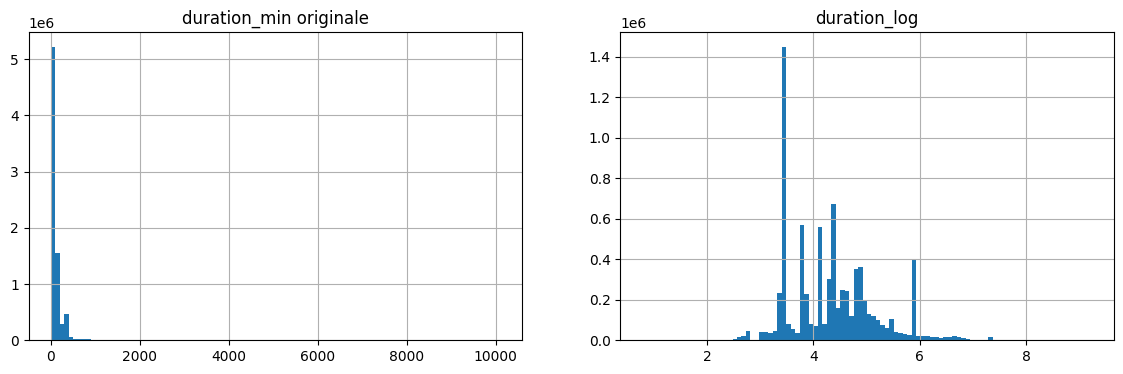

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['duration_min'].hist(bins=100, ax=axes[0])
axes[0].set_title('duration_min originale')
np.log1p(df['duration_min']).hist(bins=100, ax=axes[1])
axes[1].set_title('duration_log')
plt.show()

In [8]:
df['duration_log'] = np.log1p(df['duration_min'])
df.drop(columns=['duration_min'], inplace=True)

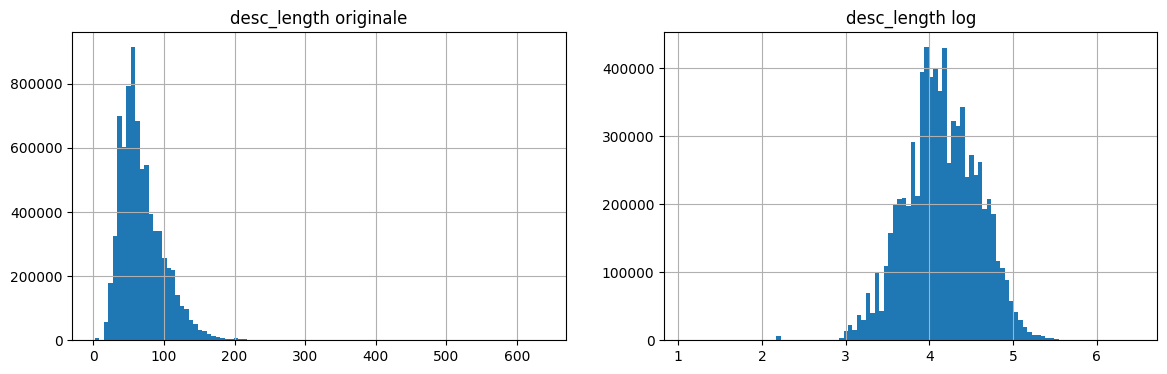

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['desc_length'].hist(bins=100, ax=axes[0])
axes[0].set_title('desc_length originale')
np.log1p(df['desc_length']).hist(bins=100, ax=axes[1])
axes[1].set_title('desc_length log')
plt.show()

In [10]:
df['desc_length_log'] = np.log1p(df['desc_length'])
df.drop(columns=['desc_length'], inplace=True)

In [11]:
for col in ['Timezone', 'Weather_Group', 'Street_Type']:
    df[col] = df[col].astype('category')

# Alta cardinalità → frequency encoding
for col in ['City', 'County', 'State', 'Zipcode']:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)

## SPLIT AND MODEL

In [12]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

X = df.drop(columns=['Severity'])
y = df['Severity'] - 1  # classi 0,1,2,3 invece di 1,2,3,4

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # mantiene le proporzioni delle classi in train e test
)

# Seconda split: 80% train, 20% val (quindi 64% e 16% del totale)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape}")   # ~64%
print(f"Val:   {X_val.shape}")     # ~16%
print(f"Test:  {X_test.shape}")    # ~20%

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

base_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Poi riduci manualmente il peso della classe 0
# Prova valori tra 0.3 e 0.7 (1.0 = nessuna modifica)
scale_factor_0 = 0.2  # riduci il peso della classe 0 al 40%

sample_weights_custom = base_weights.copy()
mask_class0 = (y_train == 0).values
sample_weights_custom[mask_class0] *= scale_factor_0

# Verifica i pesi medi per classe
for cls in range(4):
    mask = (y_train == cls).values
    print(f"Classe {cls}: peso medio = {sample_weights_custom[mask].mean():.3f}")

Train: (4941803, 40)
Val:   (1235451, 40)
Test:  (1544314, 40)
Classe 0: peso medio = 5.731
Classe 1: peso medio = 0.314
Classe 2: peso medio = 1.486
Classe 3: peso medio = 9.486


In [18]:
Learnig_rate=0.05,
Num_leaves=127,
Random_state=42,
Subsample=0.8,
Colsample_bytree=0.8,
Reg_alpha=0.1,
Reg_lambda=0.1

In [19]:
model= lgb.LGBMClassifier(
    n_estimators= 500,    
    learning_rate= Learnig_rate,
    num_leaves= Num_leaves,
    min_child_samples=50,
    random_state=Random_state,
    n_jobs=6,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=Subsample,
    colsample_bytree=Colsample_bytree,
    reg_alpha=Reg_alpha,
    reg_lambda=Reg_lambda
)

In [20]:
model.fit(
    X_train, y_train,
    sample_weight=sample_weights_custom,  # ← questi invece di sample_weights
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Timezone', 'Weather_Group', 'Street_Type']
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's multi_logloss: 0.698157
[20]	valid_0's multi_logloss: 0.513797
[30]	valid_0's multi_logloss: 0.431113
[40]	valid_0's multi_logloss: 0.389584
[50]	valid_0's multi_logloss: 0.366965
[60]	valid_0's multi_logloss: 0.352004
[70]	valid_0's multi_logloss: 0.342616
[80]	valid_0's multi_logloss: 0.334762
[90]	valid_0's multi_logloss: 0.328976
[100]	valid_0's multi_logloss: 0.324634
[110]	valid_0's multi_logloss: 0.321234
[120]	valid_0's multi_logloss: 0.317984
[130]	valid_0's multi_logloss: 0.315182
[140]	valid_0's multi_logloss: 0.312775
[150]	valid_0's multi_logloss: 0.310777
[160]	valid_0's multi_logloss: 0.309127
[170]	valid_0's multi_logloss: 0.307605
[180]	valid_0's multi_logloss: 0.305967
[190]	valid_0's multi_logloss: 0.304721
[200]	valid_0's multi_logloss: 0.303454
[210]	valid_0's multi_logloss: 0.302345
[220]	valid_0's multi_logloss: 0.301133
[230]	valid_0's multi_logloss: 0.30016
[240]	valid_0's multi_loglos

,boosting_type,'gbdt'
,num_leaves,"(127,)"
,max_depth,-1
,learning_rate,"(0.05,)"
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.29      0.85      0.44     13473
  Severity 2       0.99      0.87      0.93   1230289
  Severity 3       0.72      0.93      0.81    259850
  Severity 4       0.48      0.95      0.63     40702

    accuracy                           0.88   1544314
   macro avg       0.62      0.90      0.70   1544314
weighted avg       0.92      0.88      0.89   1544314



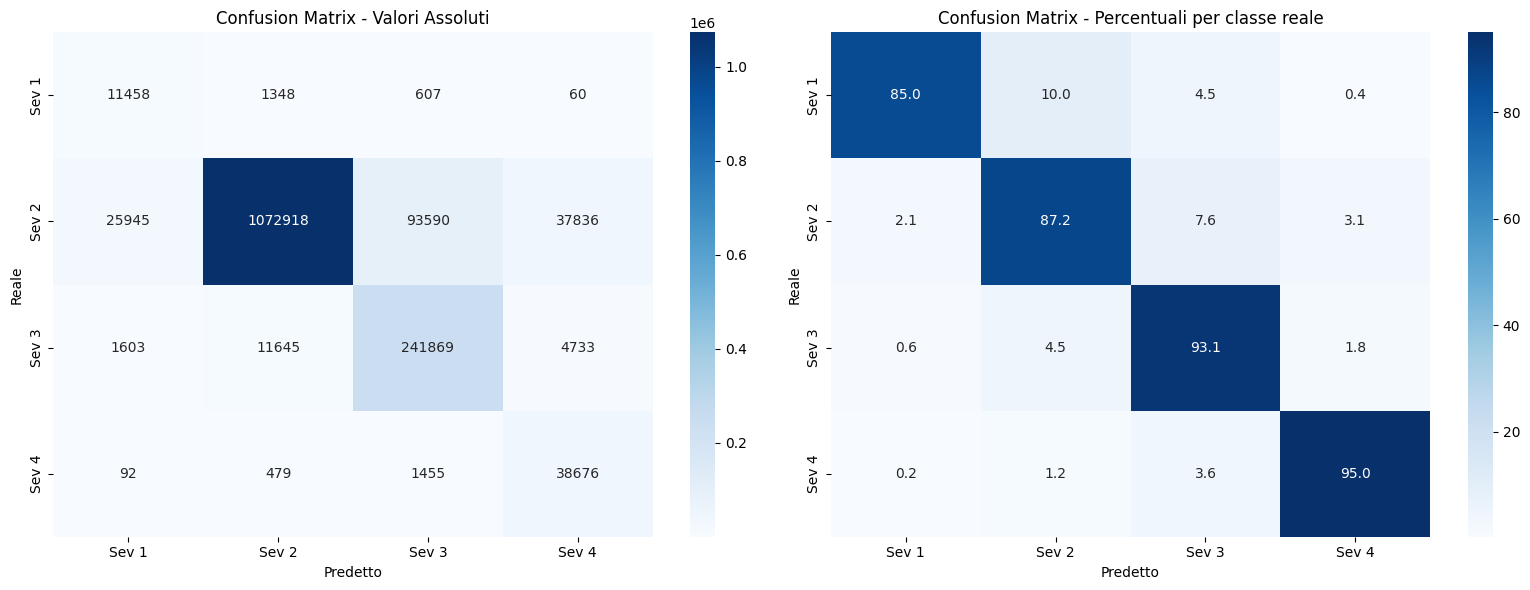


TOP 20 FEATURE IMPORTANCE
          feature  importance
     duration_log       24707
  desc_length_log       20787
        Start_Lng       18503
        Start_Lat       18212
     Pressure(in)       14800
     Distance(mi)       12649
          Zipcode       11968
      Street_Type       11943
   Temperature(F)       11239
            State       10280
           County       10040
             City       10001
             hour        9900
      Humidity(%)        9201
            month        7863
  Wind_Speed(mph)        6807
Precipitation(in)        4508
         Wind_Deg        4076
         Wind_Cos        3566
         Wind_Sin        3502


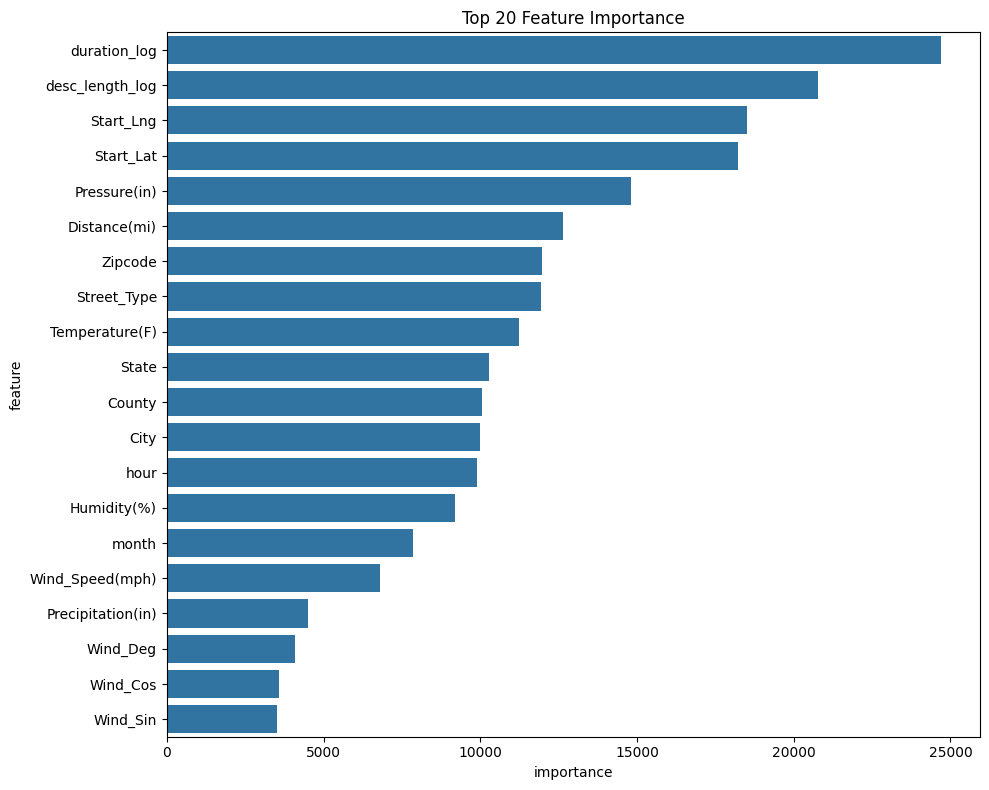

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predizioni sul test set
y_pred_test = model.predict(X_test)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valori assoluti
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

# Percentuali (più utile con classi sbilanciate)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature importance
print("\n" + "=" * 60)
print("TOP 20 FEATURE IMPORTANCE")
print("=" * 60)
feat_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

In [22]:
base_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Poi riduci manualmente il peso della classe 0
# Prova valori tra 0.3 e 0.7 (1.0 = nessuna modifica)
scale_factor_0 = 0.8  # riduci il peso della classe 0 al 40%

sample_weights_custom = base_weights.copy()
mask_class0 = (y_train == 0).values
sample_weights_custom[mask_class0] *= scale_factor_0

# Verifica i pesi medi per classe
for cls in range(4):
    mask = (y_train == cls).values
    print(f"Classe {cls}: peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0: peso medio = 22.925
Classe 1: peso medio = 0.314
Classe 2: peso medio = 1.486
Classe 3: peso medio = 9.486


In [23]:
Learnig_rate=0.05,
Num_leaves=127,
Random_state=42,
Subsample=0.8,
Colsample_bytree=0.8,
Reg_alpha=0.1,
Reg_lambda=0.1

In [24]:
model= lgb.LGBMClassifier(
    n_estimators= 500,    
    learning_rate= Learnig_rate,
    num_leaves= Num_leaves,
    min_child_samples=50,
    random_state=Random_state,
    n_jobs=6,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=Subsample,
    colsample_bytree=Colsample_bytree,
    reg_alpha=Reg_alpha,
    reg_lambda=Reg_lambda
)

In [25]:
model.fit(
    X_train, y_train,
    sample_weight=sample_weights_custom,  # ← questi invece di sample_weights
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Timezone', 'Weather_Group', 'Street_Type']
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's multi_logloss: 0.809608
[20]	valid_0's multi_logloss: 0.608665
[30]	valid_0's multi_logloss: 0.516043
[40]	valid_0's multi_logloss: 0.468098
[50]	valid_0's multi_logloss: 0.440662
[60]	valid_0's multi_logloss: 0.421343
[70]	valid_0's multi_logloss: 0.40796
[80]	valid_0's multi_logloss: 0.397344
[90]	valid_0's multi_logloss: 0.389508
[100]	valid_0's multi_logloss: 0.38339
[110]	valid_0's multi_logloss: 0.37838
[120]	valid_0's multi_logloss: 0.374375
[130]	valid_0's multi_logloss: 0.370431
[140]	valid_0's multi_logloss: 0.367129
[150]	valid_0's multi_logloss: 0.364029
[160]	valid_0's multi_logloss: 0.361462
[170]	valid_0's multi_logloss: 0.359111
[180]	valid_0's multi_logloss: 0.356703
[190]	valid_0's multi_logloss: 0.354911
[200]	valid_0's multi_logloss: 0.35307
[210]	valid_0's multi_logloss: 0.351389
[220]	valid_0's multi_logloss: 0.349808
[230]	valid_0's multi_logloss: 0.348056
[240]	valid_0's multi_logloss: 

,boosting_type,'gbdt'
,num_leaves,"(127,)"
,max_depth,-1
,learning_rate,"(0.05,)"
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.19      0.93      0.31     13473
  Severity 2       0.99      0.85      0.92   1230289
  Severity 3       0.72      0.92      0.81    259850
  Severity 4       0.47      0.95      0.63     40702

    accuracy                           0.87   1544314
   macro avg       0.59      0.91      0.67   1544314
weighted avg       0.92      0.87      0.89   1544314



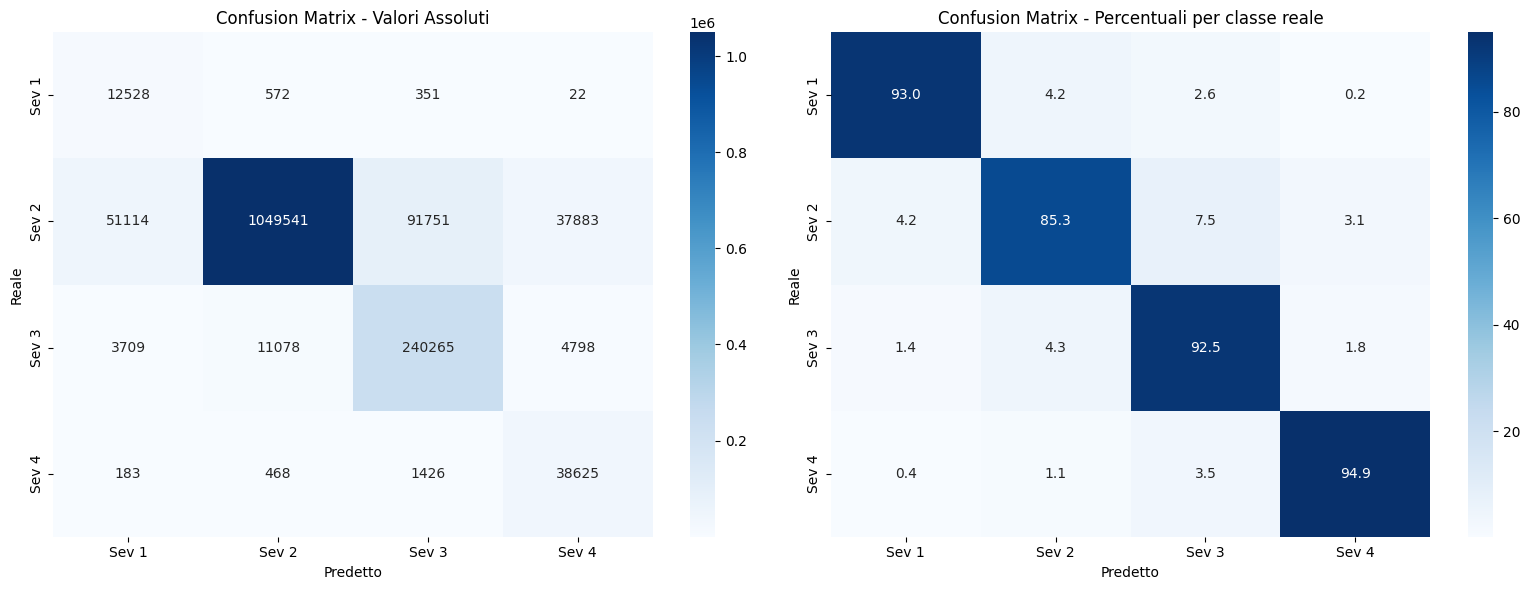


TOP 20 FEATURE IMPORTANCE
          feature  importance
     duration_log       24415
  desc_length_log       20592
        Start_Lat       17869
        Start_Lng       17865
     Pressure(in)       14528
      Street_Type       13311
          Zipcode       11842
   Temperature(F)       11803
     Distance(mi)       11684
           County       10196
             City       10078
            State       10056
             hour        9890
      Humidity(%)        9427
            month        8037
  Wind_Speed(mph)        7003
Precipitation(in)        4426
         Wind_Deg        4197
         Wind_Cos        3626
         Wind_Sin        3567


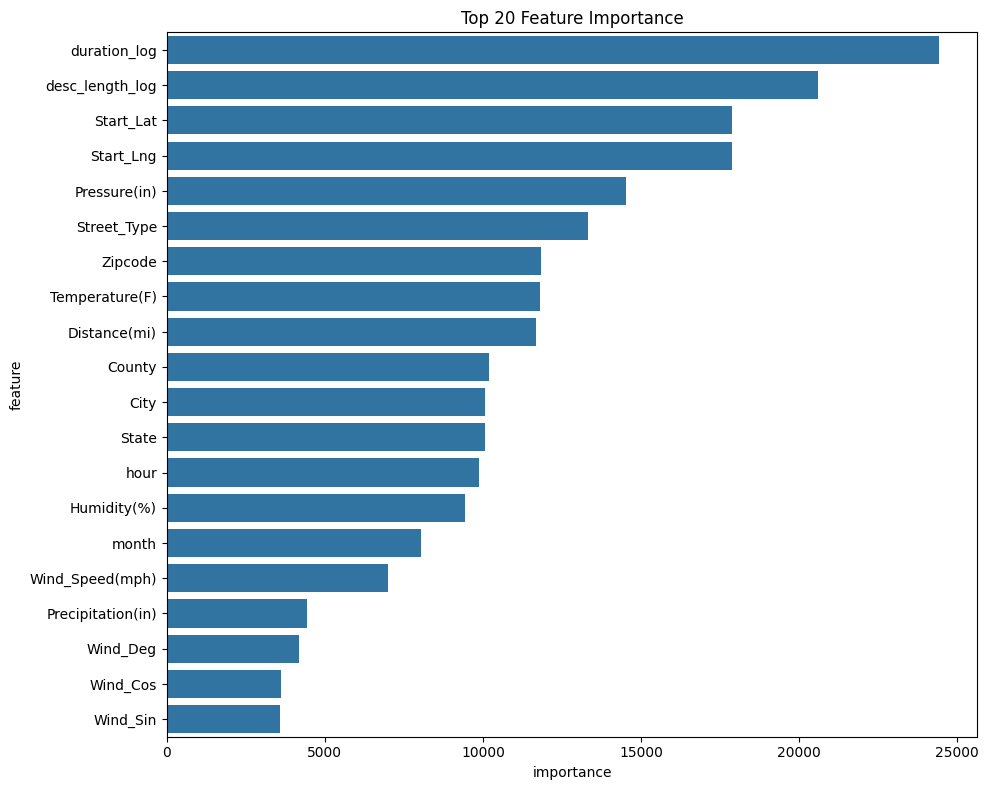

In [26]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predizioni sul test set
y_pred_test = model.predict(X_test)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
print(classification_report(y_test, y_pred_test,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valori assoluti
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

# Percentuali (più utile con classi sbilanciate)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentuali per classe reale')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature importance
print("\n" + "=" * 60)
print("TOP 20 FEATURE IMPORTANCE")
print("=" * 60)
feat_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

In [14]:
import optuna
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

def train_and_evaluate(params):
    model_opt = lgb.LGBMClassifier(**params)
    
    sw = compute_sample_weight(class_weight='balanced', y=y_train)
    sw[(y_train == 0).values] *= 0.2
    
    model_opt.fit(
        X_train, y_train,
        sample_weight=sw,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=999999)  # silenzia il log
        ],
        categorical_feature=['Timezone', 'Weather_Group', 'Street_Type']
    )
    
    y_pred = model_opt.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    f1_per_class = f1_score(y_val, y_pred, average=None)
    return f1, f1_per_class

# Parametri base fissi
base_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 127,
    'min_child_samples': 50,
    'max_depth': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'objective': 'multiclass',
    'num_class': 4,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'device': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0
}

# Griglia di confronto per ogni parametro
experiments = {
    'max_depth':        [6, 15],
    'subsample':        [0.6,1.0],
    'colsample_bytree': [0.6,1.0],
    'reg_alpha':        [0.01,0.5],
    'reg_lambda':       [0.01,0.5],
}

results = []

for param_name, values in experiments.items():
    print(f"\n{'='*50}")
    print(f"Testando: {param_name}")
    print(f"{'='*50}")
    
    for val in values:
        params = base_params.copy()
        params[param_name] = val
        
        f1, f1_classes = train_and_evaluate(params)
        
        results.append({
            'param': param_name,
            'value': val,
            'macro_f1': f1,
            'f1_sev1': f1_classes[0],
            'f1_sev2': f1_classes[1],
            'f1_sev3': f1_classes[2],
            'f1_sev4': f1_classes[3]
        })
        
        print(f"  {param_name}={val:6} → macro_f1={f1:.4f} | "
              f"Sev1={f1_classes[0]:.3f} Sev2={f1_classes[1]:.3f} "
              f"Sev3={f1_classes[2]:.3f} Sev4={f1_classes[3]:.3f}")

# Riepilogo finale
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("RIEPILOGO - TOP 10 CONFIGURAZIONI PER MACRO F1")
print("="*50)
print(results_df.sort_values('macro_f1', ascending=False).head(10).to_string(index=False))


Testando: max_depth
Training until validation scores don't improve for 50 rounds


LightGBMError: Check failed: (best_split_info.left_count) > (0) at D:\a\1\s\lightgbm-python\src\treelearner\serial_tree_learner.cpp, line 852 .
